# Santander 고객 만족 — 5개 모델 최종 비교

LightGBM 기준(HyperOpt 튜닝값)에 맞춰 XGBoost/RandomForest/LogisticRegression/GradientBoost를 동일 조건으로 평가한다. 분류 임계값은 극단적 불균형(TARGET=1 ≈ 3.96%)을 반영해 기본값 0.5 대신 양성 클래스 기저율로 설정한다.

In [1]:
import numpy as np
import pandas as pd
import warnings
import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score

_start_time = datetime.datetime.now()
print(f'[전체 실행 시작] {_start_time}')


[전체 실행 시작] 2026-08-28 17:28:32.369775


In [2]:
print(f'[1. 데이터 로드·전처리 시작] {datetime.datetime.now()}')
# 데이터 로드 + 최소 전처리(이상치 치환, ID 제거)
df = pd.read_csv("../data/santander-customer-satisfaction/train.csv", encoding='latin-1')
df['var3'] = df['var3'].replace(-999999, 2)
df = df.drop(columns='ID')

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 피처 정제: 분산0 제거 -> 중복 컬럼 제거 -> 희소(99% 이상 0) 컬럼 제거
X = X.loc[:, X.std() != 0]
X = X.T.drop_duplicates().T
X = X.loc[:, (X == 0).mean() < 0.99]


[1. 데이터 로드·전처리 시작] 2026-08-28 17:28:32.378420


In [3]:
print(f'[2. 데이터 분할 시작] {datetime.datetime.now()}')
# 분할: 최종 검증용(X_test)과 학습용(X_train) 분리, 학습용은 다시 조기종료 검증용(X_val)으로 재분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)


[2. 데이터 분할 시작] 2026-08-28 17:28:46.373229


In [4]:
print(f'[3. LightGBM 학습 시작] {datetime.datetime.now()}')
# LightGBM: HyperOpt(TPE, 50회 탐색)로 찾은 최적 하이퍼파라미터
lgbm = LGBMClassifier(
    n_estimators=500, num_leaves=32, max_depth=113, min_child_samples=83,
    subsample=0.9533, learning_rate=0.12555, random_state=156, verbose=-1,
)
lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
         callbacks=[lgb.early_stopping(100, verbose=False)]);


[3. LightGBM 학습 시작] 2026-08-28 17:28:46.536834


In [5]:
print(f'[4. XGBoost 학습 시작] {datetime.datetime.now()}')
# XGBoost: LightGBM과 대등한 모델 용량(트리 개수/깊이)으로 맞춘 설정
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=100,
    eval_metric='auc', random_state=156,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False);


[4. XGBoost 학습 시작] 2026-08-28 17:28:48.786272


In [6]:
print(f'[5. GradientBoost 학습 시작] {datetime.datetime.now()}')
# GradientBoost: XGBoost와 동일한 트리 용량, 조기종료는 내부 validation_fraction으로 처리
gb = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
    random_state=156, n_iter_no_change=100, validation_fraction=0.1,
)
gb.fit(X_train, y_train);


[5. GradientBoost 학습 시작] 2026-08-28 17:28:50.433838


In [7]:
print(f'[6. RandomForest 학습 시작] {datetime.datetime.now()}')
# RandomForest: 배깅 계열은 조기종료가 없어 학습셋 전체를 사용, 깊이를 제한하지 않아 소수 클래스 신호를 포착할 여지를 남긴다
rf = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=3, max_features='sqrt',
    n_jobs=-1, random_state=156,
)
rf.fit(X_train, y_train);


[6. RandomForest 학습 시작] 2026-08-28 17:30:11.540565


In [8]:
print(f'[7. LogisticRegression 학습 시작] {datetime.datetime.now()}')
# LogisticRegression: 피처 스케일 차이가 큰 데이터라 StandardScaler를 반드시 함께 쓴다(트리 모델과 달리 스케일에 민감)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=156))
lr.fit(X_train, y_train);


[7. LogisticRegression 학습 시작] 2026-08-28 17:30:21.584336


In [9]:
print(f'[8. 임계값 적용 및 평가 시작] {datetime.datetime.now()}')
# 분류 임계값: 극단적 불균형(TARGET=1 기저율)에 맞춰 0.5 대신 기저율을 사용
threshold = y_train.mean()

def evaluate(model, X, y, thr):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= thr).astype(int)
    return {
        'Accuracy': accuracy_score(y, pred),
        'AUC': roc_auc_score(y, proba),
        'Recall': recall_score(y, pred),
        'F1': f1_score(y, pred),
        '임계값': thr,
    }

results = {
    'LightGBM': evaluate(lgbm, X_test, y_test, threshold),
    '로지스틱 회귀': evaluate(lr, X_test, y_test, threshold),
    'XGBoost': evaluate(xgb, X_test, y_test, threshold),
    '랜덤포레스트': evaluate(rf, X_test, y_test, threshold),
    'GradientBoost': evaluate(gb, X_test, y_test, threshold),
}

result_df = pd.DataFrame(results).T.loc[
    ['LightGBM', '로지스틱 회귀', 'XGBoost', '랜덤포레스트', 'GradientBoost']
]
print(result_df.to_string())


[8. 임계값 적용 및 평가 시작] 2026-08-28 17:30:23.626451


               Accuracy       AUC    Recall        F1       임계값
LightGBM       0.779663  0.841748  0.744479  0.219842  0.039036
로지스틱 회귀        0.696922  0.806152  0.753943  0.171819  0.039036
XGBoost        0.769797  0.844977  0.763407  0.216652  0.039036
랜덤포레스트         0.730005  0.834930  0.776025  0.193358  0.039036
GradientBoost  0.797882  0.839995  0.717666  0.228471  0.039036


In [10]:
# 전체 실행 종료 시각 + 총 소요시간
_end_time = datetime.datetime.now()
print(f'[전체 실행 종료] {_end_time}')
print(f'[총 소요시간] {_end_time - _start_time}')


[전체 실행 종료] 2026-08-28 17:30:24.357241
[총 소요시간] 0:01:51.987466


## 5개 모델 — ROC Curve

이진분류 모델 평가에서 가장 일반적으로 쓰이는 표준 그래프. 곡선이 왼쪽 위 모서리에 가까울수록(점선 대각선=무작위 추측 기준선에서 멀수록) 판별력이 좋은 모델이다. 범례의 AUC 값이 §위 성능표의 AUC와 일치해야 한다.

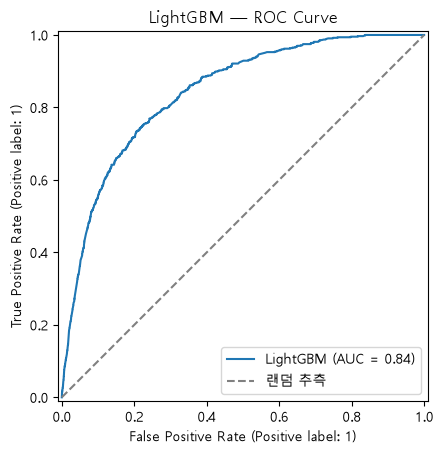

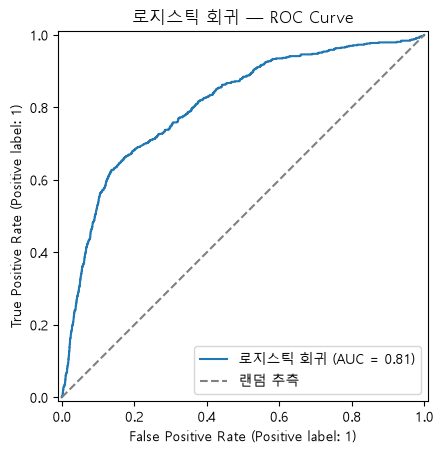

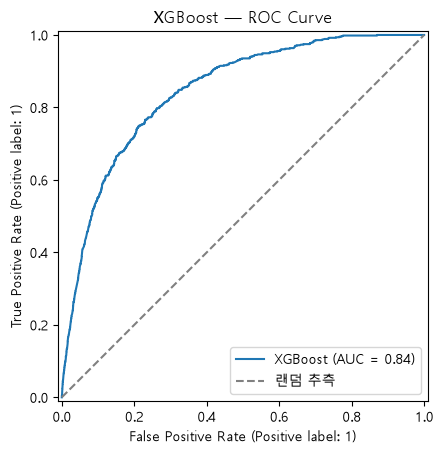

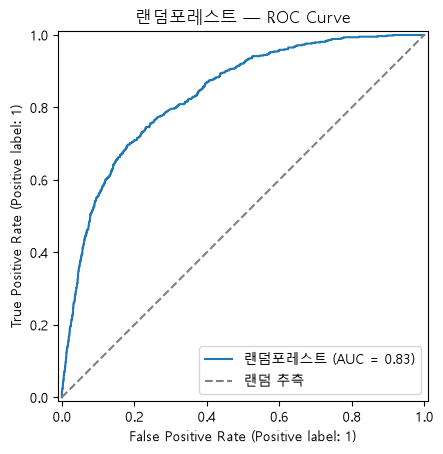

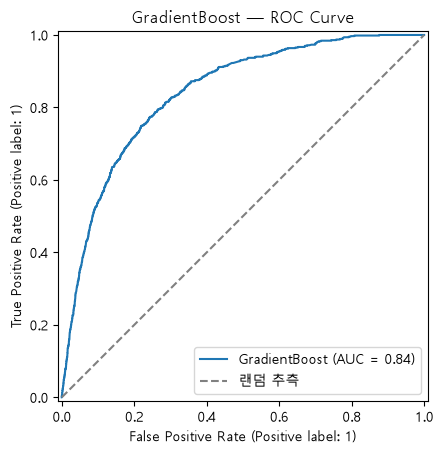

In [12]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='랜덤 추측')
    plt.title(f'{name} — ROC Curve')
    plt.legend()
    plt.show()
